To run this, press "*Runtime*" and press "*Run all*" on a Google Colab L4 instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install --no-deps transformers==5.5.0
!pip install torchcodec
import torch; torch._dynamo.config.recompile_limit = 64;

In [2]:
%%capture
!pip install --no-deps --upgrade timm # For Gemma 4 vision/audio

In [3]:
from google.colab import userdata
import wandb
import os

# Login to your WandB account
wandb.login(userdata.get('WANDB_API_KEY'))

# Configure project settings
os.environ["WANDB_PROJECT"] = "gemma4-E2B-LPR-SFT"
os.environ["WANDB_LOG_MODEL"] = "checkpoint"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: xebia-shriansh (xebia-shriansh-self) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Unsloth

In [4]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

gemma4_models = [
    # Gemma-4 instruct models:
    "unsloth/gemma-4-E2B-it",
    "unsloth/gemma-4-E4B-it",
    "unsloth/gemma-4-31B-it",
    "unsloth/gemma-4-26B-A4B-it",
    # Gemma-4 base models:
    "unsloth/gemma-4-E2B",
    "unsloth/gemma-4-E4B",
    "unsloth/gemma-4-31B",
    "unsloth/gemma-4-26B-A4B",
] # More models at https://huggingface.co/unsloth

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-4-E2B-it",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

We now add LoRA adapters for parameter efficient fine-tuning, allowing us to train only 1% of all model parameters efficiently.

**[NEW]** We also support fine-tuning only the vision component, only the language component, or both. Additionally, you can choose to fine-tune the attention modules, the MLP layers, or both!

In [5]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 32,                           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 64,                  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,               # We support rank stabilized LoRA
    loftq_config = None,               # And LoftQ
    target_modules = "all-linear",    # Optional now! Can specify a list if needed
)

<a name="Data"></a>
### Data Prep
In the original notebook by Unsloth, they used a LateX based dataset to infer math formulae from images.

In our case, we are using the a License Plate Recognition dataset to extract the number plate number from images.
The link to the dataset is as follows: [EZCon/taiwan-license-plate-recognition](https://huggingface.co/datasets/EZCon/taiwan-license-plate-recognition)

In [6]:
from datasets import load_dataset
dataset = load_dataset("EZCon/taiwan-license-plate-recognition", split = "train")
dataset = dataset.train_test_split(test_size=100)

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Let's take an overview of the dataset. We'll examine the second image and its corresponding caption.

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'xywhr', 'license_number', 'is_electric_car'],
        num_rows: 1712
    })
    test: Dataset({
        features: ['image', 'xywhr', 'license_number', 'is_electric_car'],
        num_rows: 100
    })
})

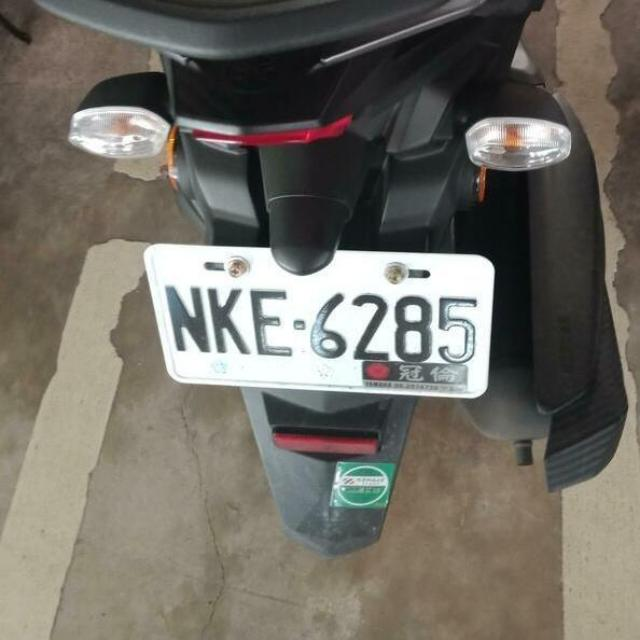

In [8]:
dataset['train'][2]["image"]

In [9]:
dataset['train'][2]["license_number"]

'NKE-6285'

To format the dataset, all vision fine-tuning tasks should follow this format:

```python
[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
]
```

In [10]:
instruction = "Extract the number plate number from this image."

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": sample["license_number"]}]},
    ]
    return {"messages": conversation}
pass

Let's convert the dataset into the "correct" format for finetuning:

In [11]:
converted_train_dataset = [convert_to_conversation(sample) for sample in dataset["train"]]
converted_test_dataset = [convert_to_conversation(sample) for sample in dataset["test"]]

The first example is now structured like below:

In [12]:
converted_train_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Extract the number plate number from this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x640>}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'EWA-8239'}]}]}

Lets take the Gemma 4 instruction chat template and use it in our base model

In [13]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-4"
)

Before fine-tuning, let us evaluate the base model's performance. We do not expect strong results, as it has not encountered this chat template before.

In [14]:
image = dataset['train'][2]["image"]
instruction = "Extract the number plate number from this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

The number plate number in the image is **NKE-6285**.<turn|>


In [15]:
dataset['train'][2]["license_number"]

'NKE-6285'

You can see that while this output is correct, we want to train the model further on SFT so that its accuracy is improved and also so that the output of the model is only the license number as per the training dataset

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [17]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = converted_train_dataset,
    eval_dataset = converted_test_dataset,
    processing_class = processor.tokenizer,
    data_collator = UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 8,
        per_device_eval_batch_size=8,
        eval_strategy="steps",
        eval_steps=1,
        max_grad_norm = 0.3,
        warmup_ratio = 0.03,
        max_steps = 15,
        # num_train_epochs = 2, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        save_steps=1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs_evaluated",
        report_to = "wandb", # For Weights and Biases or others
        run_name="gemma4-E2B-LPR-SFT",

        # You MUST put the below items for vision finetuning.
        # This disables the trainer to affect the tokenization since this trainer doesn't work properly with multimodal inputs such as images
        # We are instead relying on the chat template that we created previously as well as Unsloth's Vision Data Collator
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512


In [18]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
7.691 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()
wandb.finish()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,712 | Num Epochs = 1 | Total steps = 15
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 59,719,680 of 5,182,897,696 (1.15% trained)


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
1,16.406219,5.713207
2,16.525412,5.713207
3,16.583027,5.713207
4,16.418524,5.724415
5,9.955702,5.718635


wandb: Adding directory to artifact (outputs_evaluated/checkpoint-1)... Done. 20.8s
wandb: Adding directory to artifact (outputs_evaluated/checkpoint-2)... Done. 22.4s
wandb: Adding directory to artifact (outputs_evaluated/checkpoint-3)... Done. 29.1s
wandb: Adding directory to artifact (outputs_evaluated/checkpoint-4)... Done. 25.1s
wandb: Adding directory to artifact (outputs_evaluated/checkpoint-5)... Done. 24.7s


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

448.6135 seconds used for training.
7.48 minutes used for training.
Peak reserved memory = 11.969 GB.
Peak reserved memory for training = 4.278 GB.
Peak reserved memory % of max memory = 82.188 %.
Peak reserved memory for training % of max memory = 29.376 %.


In [ ]:
trainer_stats

TrainOutput(global_step=15, training_loss=6.4985724528630575, metrics={'train_runtime': 448.6135, 'train_samples_per_second': 2.14, 'train_steps_per_second': 0.033, 'total_flos': 3991442500915200.0, 'train_loss': 6.4985724528630575})

<a name="Inference"></a>
### Inference
Let's run the model! You can modify the instruction and input—just leave the output blank.

We'll use the best hyperparameters for inference on Gemma: `top_p=0.95`, `top_k=64`, and `temperature=1.0`.

In [ ]:
image = dataset['test'][0]["image"]
instruction = "Extract the number plate number from this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]

input_text = processor.apply_chat_template(messages, add_generation_prompt = True)

inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

3496 UK<turn|>


In [ ]:
dataset['test'][0]['license_number']

'3496-UK'

<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, use Hugging Face’s `push_to_hub` for online saving, or `save_pretrained` for local storage.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("gemma_4_E2B_LPR_evaluated")  # Local saving
processor.save_pretrained("gemma_4_E2B_LPR_evaluated")
# model.push_to_hub("your_name/gemma_4_lora", token = "YOUR_HF_TOKEN") # Online saving
# processor.push_to_hub("your_name/gemma_4_lora", token = "YOUR_HF_TOKEN") # Online saving

['gemma_4_E2B_LPR_lora/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel

    model, processor = FastVisionModel.from_pretrained(
        model_name = "gemma_4_lora",  # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True,  # Set to False for 16bit LoRA
    )

sample = dataset['train'][1]
image = sample["image"].convert("RGB")
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": sample["text"],
            },
            {
                "type": "image",
            },
        ],
    },
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor.tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

This equation appears to be from a field of physics, likely **theoretical physics**, specifically **electrodynamics**, **gauge theories**, or **relativistic field theory**, given the use of Greek letters ($\mu, \alpha, \beta$), tensor notation ($D^\alpha_\mu \tilde{A}^\alpha_\mu$), and the structure of the equation.

Here is a breakdown of the components and the likely physical meaning:

### Breakdown of the Equation

$$D^\alpha_\mu \tilde{A}^\alpha_\mu = 0$$

1.  **$D^\alpha_\mu$ (Covariant Derivative or Differential


In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, processor = FastVisionModel.from_pretrained(
    "gemma_4_E2B_LPR_lora",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    # use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
from huggingface_hub import ModelCard, ModelCardData, whoami
from google.colab import userdata


# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
# if False: model.save_pretrained_merged("unsloth_finetune", processor,)

# # To export and save to your Hugging Face account
username = whoami()['name']
hf_repo_id = f"{username}/gemma_4_E2B_LPR_evaluated"
if True: repo_url = model.push_to_hub_merged(hf_repo_id, processor, token = userdata.get('HF_TOKEN'))

# card_content = f"""
# ---
# base_model: unsloth/gemma-4-E2B-it
# tags:
# - text-generation
# - LPR
# - SFT
# - gemma
# ---
# A fine-tuned LoRA based on `unsloth/gemma-4-E2B-it` on the EZCon/taiwan-license-plate-recognition dataset for License plate recognition and extraction."""
# card = ModelCard(card_content)
# card.push_to_hub(hf_repo_id)

print(f"Uploaded to {repo_url}")

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2grnf685/tokenizer.json:  50%|####9     | 16.0MB / 32.2MB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0005-of-00005.safetensors:   0%|          | 37.0kB /  968MB            

Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [10:21<00:00, 124.21s/it]


Unsloth: Regenerating safetensors index...
Unsloth: Merge process complete. Saved to `/tmp/tmp2grnf685`
Uploaded to None


And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).